In [11]:
!hostname


login.curta.zedat.fu-berlin.de


In [21]:

import os

os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"


from photometry.models.baselines import LunarLambertModel
from photometry.fitting.least_sq import LeastSquaresFitter
from photometry.core.types import GeometryBatch


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path

import os
print(os.getcwd())

/home/kaushim07/photometry_mcmc_env/notebooks


In [22]:
# Locate aggregated phase-curve CSVs

project_root = Path.cwd().resolve()
if not (project_root / "data").exists() and (project_root.parent / "data").exists():
    project_root = project_root.parent
data_root = project_root / "data" / "05_aggregated"
csv_files = sorted(data_root.glob("*_phase_curve.csv"))
phase_dfs = {}
for path in csv_files:
    phase = path.stem.replace("_phase_curve", "").lower()
    phase_dfs[phase] = pd.read_csv(path)

# Ensure phase DataFrames exist
df_rc = phase_dfs.get("rc", pd.DataFrame()).copy()
df_survey = phase_dfs.get("survey", pd.DataFrame()).copy()
df_hamo = phase_dfs.get("hamo", pd.DataFrame()).copy()
df_lamo = phase_dfs.get("lamo", pd.DataFrame()).copy()

# Apply incidence quality filter: mean_incidence <= 60.0 degrees
def apply_incidence_filter(df):
    if df is None or df.empty:
        return df
    return df[(df["mean_incidence"] <= 60.0) & (df["median_iof"] > 0.01)].dropna().copy()

rc_f = apply_incidence_filter(df_rc)
survey_f = apply_incidence_filter(df_survey)
hamo_f = apply_incidence_filter(df_hamo)
lamo_f = apply_incidence_filter(df_lamo)


print("RC, Survey, HAMO, and LAMO phase-curve data (first 5 rows each):\n")
display(df_rc.head())
display(df_survey.head())    
display(df_hamo.head())
display(df_lamo.head())

print("\nAfter applying incidence quality filter (mean_incidence <= 60.0 degrees) and (median_iof > 0.01):\n")

display(rc_f.head())
display(survey_f.head())    
display(hamo_f.head())
display(lamo_f.head())


# Extract n_pixels array from each phase DataFrame
    
rc_n_pixels = rc_f["n_pixels"].to_numpy(dtype=float) if "n_pixels" in rc_f.columns else None
survey_n_pixels = survey_f["n_pixels"].to_numpy(dtype=float) if "n_pixels" in survey_f.columns else None
hamo_n_pixels = hamo_f["n_pixels"].to_numpy(dtype=float) if "n_pixels" in hamo_f.columns else None
lamo_n_pixels = lamo_f["n_pixels"].to_numpy(dtype=float) if "n_pixels" in lamo_f.columns else None


n_pixels_arrays = [rc_n_pixels, survey_n_pixels, hamo_n_pixels, lamo_n_pixels]
print("n_pixels_arrays:", n_pixels_arrays)

RC, Survey, HAMO, and LAMO phase-curve data (first 5 rows each):



,phase_bin_deg,n_pixels,median_iof,iof_q25,iof_q75,mean_incidence,mean_emission,mean_phase,stddev_phase
0,5.0,176610,0.153111,0.148464,0.157871,71.626347,66.758334,5.114231,0.094291
1,5.5,666541,0.156039,0.150362,0.162856,63.232285,58.376821,5.530364,0.141122
2,6.0,1161459,0.158313,0.152694,0.164295,56.575414,51.795269,6.018118,0.143254
3,6.5,1672728,0.158304,0.152456,0.165015,51.476546,46.875979,6.512820,0.143740
4,7.0,2181162,0.157746,0.151293,0.165099,47.177785,42.928023,7.009494,0.144009


,phase_bin_deg,n_pixels,median_iof,iof_q25,iof_q75,mean_incidence,mean_emission,mean_phase,stddev_phase
0,8.0,163084,0.127764,0.121919,0.132857,44.651761,37.681212,8.313530,0.127900
1,9.0,874208,0.129695,0.123402,0.136492,41.333485,34.328091,9.054928,0.283673
2,10.0,1756912,0.133439,0.126205,0.142761,38.814568,31.536061,10.069156,0.279871
3,11.0,2833907,0.134607,0.126649,0.142374,35.978741,28.967223,11.027184,0.286223
4,12.0,3634362,0.134512,0.124658,0.143150,32.712833,27.238264,12.016458,0.289264


,phase_bin_deg,n_pixels,median_iof,iof_q25,iof_q75,mean_incidence,mean_emission,mean_phase,stddev_phase
0,19.0,42045,0.110105,0.106279,0.114559,51.648175,33.960879,19.446580,0.039433
1,20.0,2598714,0.107980,0.103248,0.113012,50.349700,32.887181,20.128212,0.257699
2,21.0,6324931,0.112733,0.107491,0.117502,47.310793,29.454187,21.044422,0.283905
3,22.0,7677986,0.112669,0.107517,0.118399,41.535133,23.917346,21.999951,0.288678
4,23.0,7678365,0.113152,0.106977,0.120662,34.173785,18.487663,23.000286,0.288829


,phase_bin_deg,n_pixels,median_iof,iof_q25,iof_q75,mean_incidence,mean_emission,mean_phase,stddev_phase
0,27.0,1893773,0.096468,0.088802,0.103189,39.854174,22.729714,27.118177,0.243559
1,28.0,3403287,0.093369,0.085087,0.102391,37.828540,21.645932,28.024512,0.286757
2,29.0,4281461,0.092531,0.084355,0.101292,36.102878,20.928407,29.014964,0.288129
3,30.0,5008024,0.092620,0.084336,0.101277,34.603879,20.573412,30.010433,0.288535
4,31.0,5640772,0.091657,0.084025,0.099982,33.260396,20.540697,31.009144,0.288751


...

,phase_bin_deg,n_pixels,median_iof,iof_q25,iof_q75,mean_incidence,mean_emission,mean_phase,stddev_phase
2,6.0,1161459,0.158313,0.152694,0.164295,56.575414,51.795269,6.018118,0.143254
3,6.5,1672728,0.158304,0.152456,0.165015,51.476546,46.875979,6.512820,0.143740
4,7.0,2181162,0.157746,0.151293,0.165099,47.177785,42.928023,7.009494,0.144009
5,7.5,2659699,0.156670,0.149955,0.163351,43.457700,39.861136,7.507199,0.144115
6,8.0,3092602,0.155345,0.148001,0.162069,40.491482,38.185382,8.005482,0.144191


,phase_bin_deg,n_pixels,median_iof,iof_q25,iof_q75,mean_incidence,mean_emission,mean_phase,stddev_phase
0,8.0,163084,0.127764,0.121919,0.132857,44.651761,37.681212,8.313530,0.127900
1,9.0,874208,0.129695,0.123402,0.136492,41.333485,34.328091,9.054928,0.283673
2,10.0,1756912,0.133439,0.126205,0.142761,38.814568,31.536061,10.069156,0.279871
3,11.0,2833907,0.134607,0.126649,0.142374,35.978741,28.967223,11.027184,0.286223
4,12.0,3634362,0.134512,0.124658,0.143150,32.712833,27.238264,12.016458,0.289264


,phase_bin_deg,n_pixels,median_iof,iof_q25,iof_q75,mean_incidence,mean_emission,mean_phase,stddev_phase
0,19.0,42045,0.110105,0.106279,0.114559,51.648175,33.960879,19.446580,0.039433
1,20.0,2598714,0.107980,0.103248,0.113012,50.349700,32.887181,20.128212,0.257699
2,21.0,6324931,0.112733,0.107491,0.117502,47.310793,29.454187,21.044422,0.283905
3,22.0,7677986,0.112669,0.107517,0.118399,41.535133,23.917346,21.999951,0.288678
4,23.0,7678365,0.113152,0.106977,0.120662,34.173785,18.487663,23.000286,0.288829


,phase_bin_deg,n_pixels,median_iof,iof_q25,iof_q75,mean_incidence,mean_emission,mean_phase,stddev_phase
0,27.0,1893773,0.096468,0.088802,0.103189,39.854174,22.729714,27.118177,0.243559
1,28.0,3403287,0.093369,0.085087,0.102391,37.828540,21.645932,28.024512,0.286757
2,29.0,4281461,0.092531,0.084355,0.101292,36.102878,20.928407,29.014964,0.288129
3,30.0,5008024,0.092620,0.084336,0.101277,34.603879,20.573412,30.010433,0.288535
4,31.0,5640772,0.091657,0.084025,0.099982,33.260396,20.540697,31.009144,0.288751


n_pixels_arrays: [array([1161459., 1672728., 2181162., 2659699., 3092602., 3466045.,
       3765098., 3952088., 3998382., 3594699., 3169919., 2895271.,
       2591638., 2264496., 1916533., 1551323., 1180868.,  831513.,
       2830039., 3619164., 3733560., 3700865., 3662191., 3630765.,
       3599324., 3624391., 3727469., 3346726.]), array([  163084.,   874208.,  1756912.,  2833907.,  3634362.,  4555348.,
        5715947.,  6932308.,  7508790., 11457801., 14090010., 14155328.,
       12135982.,  9712427.,  9419541.,  9583059.,  9944809., 10459507.,
       11423299., 11750041., 12636785., 13353487., 13203763., 13554362.,
       12845104., 12225080., 12224699., 12195417., 11779390., 11699397.,
       11771869., 11201411., 11616249., 12424169., 12308925., 12728543.,
       12404551., 11576523., 11563653., 11786709., 11357469., 11665832.,
       12244648., 12628102., 13016027., 13024415., 12398666., 12449830.,
       12594266., 12261204., 13126783., 13652042., 13074423., 13439737.,
       1

In [23]:

phases = [("RC", rc_f), ("Survey", survey_f), ("HAMO", hamo_f), ("LAMO", lamo_f)]
fitter = LeastSquaresFitter()


results = {}
for phase_name, df_phase in phases:
    if df_phase is None or df_phase.empty:
        print(f"{phase_name}: no data after 60° incidence filter")
        continue

    incidence_rad = np.deg2rad(df_phase["mean_incidence"].to_numpy(dtype=float))
    emission_rad = np.deg2rad(df_phase["mean_emission"].to_numpy(dtype=float))
    phase_rad = np.deg2rad(df_phase["mean_phase"].to_numpy(dtype=float))

    geom_batch = GeometryBatch(
        incidence=incidence_rad,
        emission=emission_rad,
        phase=phase_rad,
    )

    observed = df_phase["median_iof"].to_numpy(dtype=float) # observed I/F values
    n_pixels = df_phase["n_pixels"].to_numpy(dtype=float) if "n_pixels" in df_phase.columns else None # weights based on n_pixels if available, else None for unweighted fit 
    #weights = np.sqrt(n_pixels)/(df_phase['iof_q75'] - df_phase['iof_q25']).replace(0, np.nan).fillna(df_phase['median_iof']*0.1) # avoid division by zero; will result in NaN weights for those points which are effectively ignored in the fit
    
    weights_series = np.sqrt(n_pixels) / (df_phase['iof_q75'] - df_phase['iof_q25']).replace(0, np.nan).fillna(df_phase['median_iof']*0.1)
    weights = weights_series.to_numpy(dtype=float) # safety cast

    model_instance = LunarLambertModel(metadata={'phase_dependent_c_L': True}) # Use phase-independent c_L for this baseline fit
    fit_result = fitter.fit(model_instance, geom_batch, observed, weights=weights) # Use unweighted fit for now; can switch to weights=weights if desired

    # Extract fitted parameters and statistics

    fitted_params = fit_result.fitted_parameters
    parameter_errors = fit_result.metadata.get("parameter_errors", {})

   

    results[phase_name] = {
        "parameters": fitted_params,
        "parameter_errors": parameter_errors,
        "n_bins": int(len(df_phase)),
        "reduced_chi_square": float(fit_result.metadata.get("reduced_chi_square")) if fit_result.metadata.get("reduced_chi_square") is not None else None,
    }



    param_str = ", ".join([f"{k} = {v:.4f}" for k, v in fitted_params.items()])
    
    print(f"{phase_name}: {param_str}; Chi2_red = {results[phase_name]['reduced_chi_square']:.4f}")


RC: albedo = 0.1470; Chi2_red = 11.8585
Survey: albedo = 0.1028; Chi2_red = 9.7322
HAMO: albedo = 0.0870; Chi2_red = 11.1163
LAMO: albedo = 0.0759; Chi2_red = 7.4808


In [24]:
results_df = pd.DataFrame.from_dict(results, orient="index")
print("\nSummary of LunarLambert fit results for each phase:")
display(results_df)


Summary of LunarLambert fit results for each phase:


,parameters,parameter_errors,n_bins,reduced_chi_square
RC,{'albedo': 0.14695539583945563},{'albedo': 0.008588860324888209},28,11.858527
Survey,{'albedo': 0.10283170156510274},{'albedo': 0.004783845942241011},74,9.732221
HAMO,{'albedo': 0.08698810374947617},{'albedo': 0.0029999645557071773},42,11.116324
LAMO,{'albedo': 0.07593847111830486},{'albedo': 0.0017641082611677755},26,7.480750


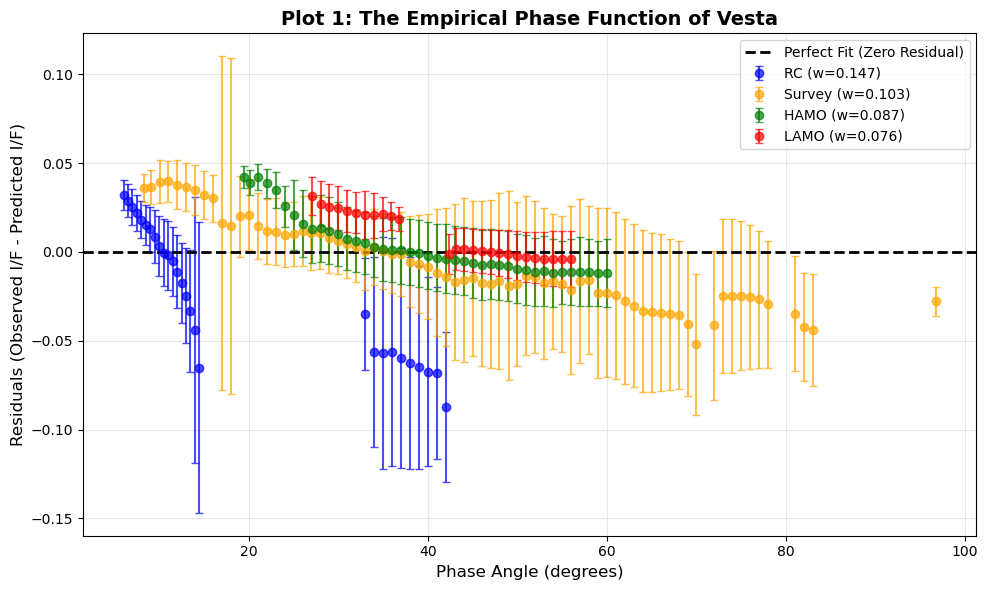

In [25]:


plt.figure(figsize=(10, 6))
colors = {"RC": "blue", "Survey": "orange", "HAMO": "green", "LAMO": "red"}

# Loop through the data to calculate residuals
for phase_name, df_phase in phases:
    if df_phase is None or df_phase.empty:
        continue
        
    # 1. Package the geometry in radians for the model
    geom_batch = GeometryBatch(
        incidence=np.deg2rad(df_phase["mean_incidence"].to_numpy(dtype=float)),
        emission=np.deg2rad(df_phase["mean_emission"].to_numpy(dtype=float)),
        phase=np.deg2rad(df_phase["mean_phase"].to_numpy(dtype=float)),
    )
    
    # 2. Re-instantiate the model using the fitted albedo for this specific phase
    # We keep phase_dependent_c_L = True so it correctly uses the Schröder relation internally
    fitted_albedo = results[phase_name]['parameters']['albedo']
    model = LunarLambertModel(
        parameters={"albedo": fitted_albedo}, 
        metadata={"phase_dependent_c_L": True}
    )
    
    # 3. Predict the I/F and calculate residuals (Observed - Predicted)
    predicted_iof = model._reflectance_numpy(geom_batch)
    observed_iof = df_phase["median_iof"].to_numpy(dtype=float)
    residuals = observed_iof - predicted_iof
    
    # 4. Calculate error bars (IQR scaled to approximate standard deviation)
    iqr = df_phase["iof_q75"] - df_phase["iof_q25"]
    errors = iqr / 1.35
    
    # 5. Plot the residuals
    plt.errorbar(
        df_phase["mean_phase"], 
        residuals, 
        yerr=errors, 
        fmt='o', 
        label=f"{phase_name} (w={fitted_albedo:.3f})", 
        color=colors[phase_name], 
        alpha=0.7,
        capsize=3
    )

# Formatting the plot
plt.axhline(0, color='black', linestyle='--', linewidth=2, label="Perfect Fit (Zero Residual)")
plt.xlabel("Phase Angle (degrees)", fontsize=12)
plt.ylabel("Residuals (Observed I/F - Predicted I/F)", fontsize=12)
plt.title("Plot 1: The Empirical Phase Function of Vesta", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

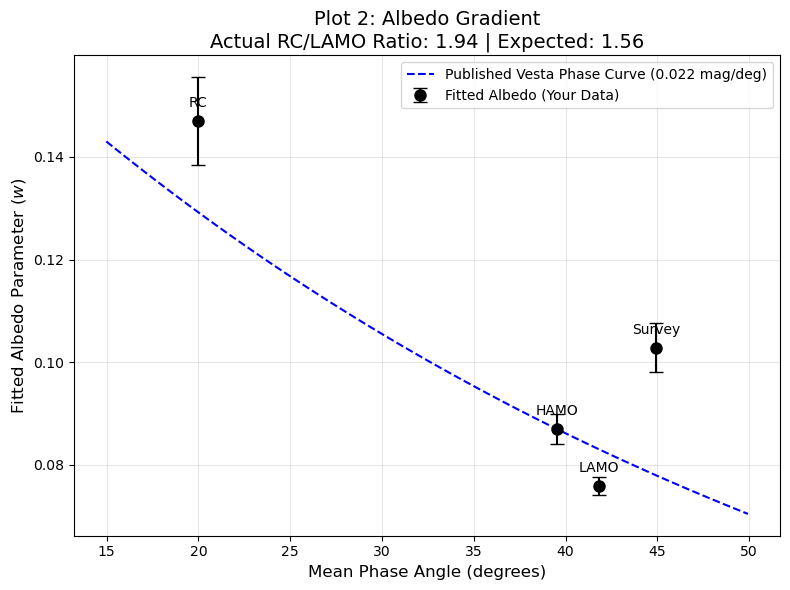

In [26]:

plt.figure(figsize=(8, 6))

# 1. Extract data for the plot
names = []
mean_phases = []
fitted_albedos = []
albedo_errors = []

for phase_name, df_phase in phases:
    if df_phase is None or df_phase.empty:
        continue
    names.append(phase_name)
    mean_phases.append(df_phase["mean_phase"].mean())
    fitted_albedos.append(results[phase_name]['parameters']['albedo'])
    albedo_errors.append(results[phase_name]['parameter_errors']['albedo'])

# 2. Plot your actual pipeline results
plt.errorbar(mean_phases, fitted_albedos, yerr=albedo_errors, fmt='o', 
             color='black', markersize=8, capsize=5, label='Fitted Albedo (Your Data)')

# 3. Calculate the theoretical published curve (normalized to HAMO)
hamo_idx = names.index("HAMO")
hamo_phase = mean_phases[hamo_idx]
hamo_albedo = fitted_albedos[hamo_idx]

phase_range = np.linspace(min(mean_phases)-5, max(mean_phases)+5, 100)
# Convert magnitude difference (0.022 mag/deg) to flux ratio
mag_diff = 0.022 * (phase_range - hamo_phase)
expected_flux_ratio = 10 ** (-0.4 * mag_diff)
expected_albedo = hamo_albedo * expected_flux_ratio

# 4. Plot the theoretical curve
plt.plot(phase_range, expected_albedo, '--', color='blue', 
         label='Published Vesta Phase Curve (0.022 mag/deg)')

# Calculate and print the RC/LAMO ratio
rc_idx, lamo_idx = names.index("RC"), names.index("LAMO")
actual_ratio = fitted_albedos[rc_idx] / fitted_albedos[lamo_idx]
mag_diff_rc_lamo = 0.022 * (mean_phases[lamo_idx] - mean_phases[rc_idx])
expected_ratio = 10 ** (0.4 * mag_diff_rc_lamo)

plt.title(f"Plot 2: Albedo Gradient\nActual RC/LAMO Ratio: {actual_ratio:.2f} | Expected: {expected_ratio:.2f}", fontsize=14)
plt.xlabel("Mean Phase Angle (degrees)", fontsize=12)
plt.ylabel("Fitted Albedo Parameter ($w$)", fontsize=12)
for i, name in enumerate(names):
    plt.annotate(name, (mean_phases[i], fitted_albedos[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

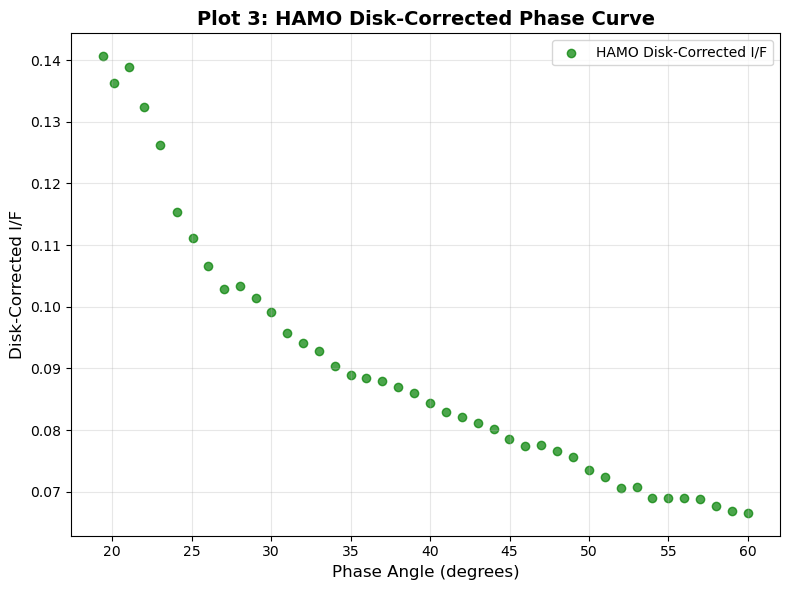

In [27]:


plt.figure(figsize=(8, 6))

df_hamo = hamo_f  # Using your filtered HAMO data
if df_hamo is not None and not df_hamo.empty:
    # Package geometry
    geom_batch = GeometryBatch(
        incidence=np.deg2rad(df_hamo["mean_incidence"].to_numpy(dtype=float)),
        emission=np.deg2rad(df_hamo["mean_emission"].to_numpy(dtype=float)),
        phase=np.deg2rad(df_hamo["mean_phase"].to_numpy(dtype=float)),
    )
    
    # Instantiate model with albedo=1.0 to extract pure disk function (D)
    model_D = LunarLambertModel(parameters={"albedo": 1.0}, metadata={"phase_dependent_c_L": True})
    pure_disk_function = model_D._reflectance_numpy(geom_batch)
    
    # Calculate disk-corrected I/F
    disk_corrected_iof = df_hamo["median_iof"].to_numpy(dtype=float) / pure_disk_function
    
    # Plot
    plt.scatter(df_hamo["mean_phase"], disk_corrected_iof, color='green', alpha=0.7, label="HAMO Disk-Corrected I/F")
    
    plt.title("Plot 3: HAMO Disk-Corrected Phase Curve", fontsize=14, fontweight='bold')
    plt.xlabel("Phase Angle (degrees)", fontsize=12)
    plt.ylabel("Disk-Corrected I/F", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

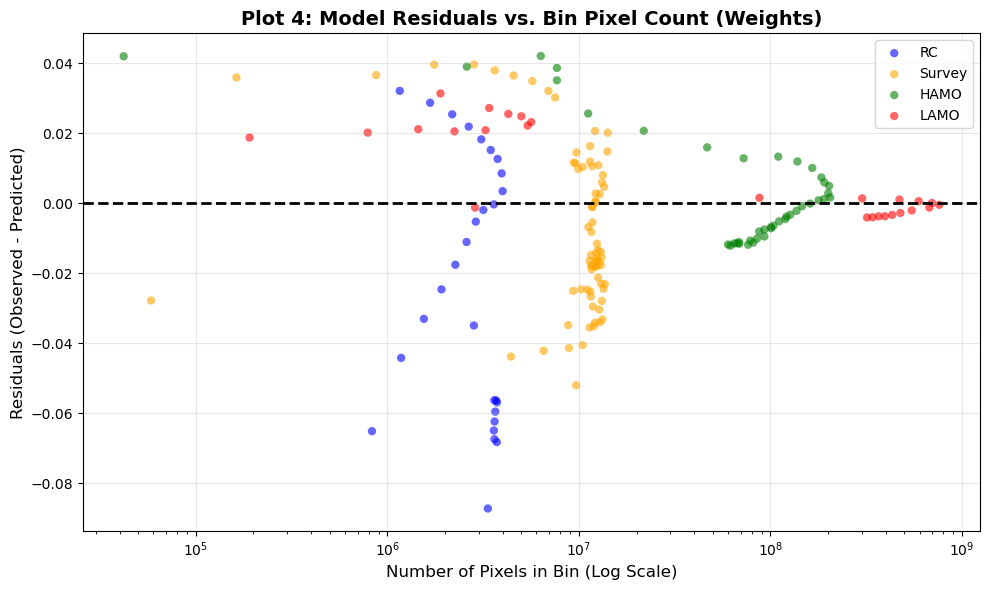

In [28]:
plt.figure(figsize=(10, 6))
colors = {"RC": "blue", "Survey": "orange", "HAMO": "green", "LAMO": "red"}

for phase_name, df_phase in phases:
    if df_phase is None or df_phase.empty or "n_pixels" not in df_phase.columns:
        continue
        
    geom_batch = GeometryBatch(
        incidence=np.deg2rad(df_phase["mean_incidence"].to_numpy(dtype=float)),
        emission=np.deg2rad(df_phase["mean_emission"].to_numpy(dtype=float)),
        phase=np.deg2rad(df_phase["mean_phase"].to_numpy(dtype=float)),
    )
    
    fitted_albedo = results[phase_name]['parameters']['albedo']
    model = LunarLambertModel(parameters={"albedo": fitted_albedo}, metadata={"phase_dependent_c_L": True})
    
    predicted_iof = model._reflectance_numpy(geom_batch)
    observed_iof = df_phase["median_iof"].to_numpy(dtype=float)
    residuals = observed_iof - predicted_iof
    
    plt.scatter(df_phase["n_pixels"], residuals, label=phase_name, color=colors[phase_name], alpha=0.6, edgecolors='none')

plt.axhline(0, color='black', linestyle='--', linewidth=2)
plt.xscale('log')
plt.title("Plot 4: Model Residuals vs. Bin Pixel Count (Weights)", fontsize=14, fontweight='bold')
plt.xlabel("Number of Pixels in Bin (Log Scale)", fontsize=12)
plt.ylabel("Residuals (Observed - Predicted)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:

from scipy.stats import pearsonr
from photometry.models.baselines import LunarLambertModel
from photometry.core.types import GeometryBatch

print("="*60)
print("LUNAR-LAMBERT SCIENTIFIC VALIDATION METRICS")
print("="*60)

# 1. Albedos and Chi-Square
print("\n1. FITTED ALBEDOS & REDUCED CHI-SQUARE")
print(f"{'Phase':<10} | {'w (Albedo)':<10} | {'Error':<10} | {'Chi^2_nu':<10}")
print("-" * 45)
for phase in ["RC", "Survey", "HAMO", "LAMO"]:
    if phase in results:
        res = results[phase]
        w = res['parameters']['albedo']
        err = res['parameter_errors']['albedo']
        chi = res['reduced_chi_square']
        print(f"{phase:<10} | {w:.4f}     | ±{err:.4f}  | {chi:.2f}")

# 2. RC to LAMO Ratio Check
rc_w = results['RC']['parameters']['albedo']
lamo_w = results['LAMO']['parameters']['albedo']
actual_ratio = rc_w / lamo_w

# Get actual mean phase angles for the ratio calculation
rc_mean_phase = phase_dfs['rc'][phase_dfs['rc']["mean_incidence"] <= 60.0]["mean_phase"].mean()
lamo_mean_phase = phase_dfs['lamo'][phase_dfs['lamo']["mean_incidence"] <= 60.0]["mean_phase"].mean()

mag_diff = 0.022 * (lamo_mean_phase - rc_mean_phase)
expected_ratio = 10 ** (0.4 * mag_diff)
percent_diff = abs(actual_ratio - expected_ratio) / expected_ratio * 100

print("\n2. ALBEDO GRADIENT VS LITERATURE (0.022 mag/deg)")
print(f"RC Mean Phase:   {rc_mean_phase:.1f} deg")
print(f"LAMO Mean Phase: {lamo_mean_phase:.1f} deg")
print(f"Actual Ratio:    {actual_ratio:.3f}")
print(f"Expected Ratio:  {expected_ratio:.3f}")
print(f"Agreement:       Within {percent_diff:.1f}%")

# 3. Residual Structure (The Empirical Phase Function)
print("\n3. RESIDUAL STRUCTURE BY PHASE ANGLE (Mean ± Std)")
print(f"{'Phase':<10} | {'< 15 deg':<15} | {'15-45 deg':<15} | {'> 45 deg':<15}")
print("-" * 65)

for phase_name, df_phase in phases:
    if df_phase is None or df_phase.empty: continue
    
    geom_batch = GeometryBatch(
        incidence=np.deg2rad(df_phase["mean_incidence"].to_numpy(dtype=float)),
        emission=np.deg2rad(df_phase["mean_emission"].to_numpy(dtype=float)),
        phase=np.deg2rad(df_phase["mean_phase"].to_numpy(dtype=float)),
    )
    
    w = results[phase_name]['parameters']['albedo']
    model = LunarLambertModel(parameters={"albedo": w}, metadata={"phase_dependent_c_L": True})
    pred = model._reflectance_numpy(geom_batch)
    resids = df_phase["median_iof"].to_numpy(dtype=float) - pred
    
    # Bins
    mask_low = df_phase["mean_phase"] < 15
    mask_mid = (df_phase["mean_phase"] >= 15) & (df_phase["mean_phase"] <= 45)
    mask_high = df_phase["mean_phase"] > 45
    
    def get_stats(mask):
        if sum(mask) == 0: return "N/A"
        return f"{np.mean(resids[mask]):.3f} ± {np.std(resids[mask]):.3f}"
        
    print(f"{phase_name:<10} | {get_stats(mask_low):<15} | {get_stats(mask_mid):<15} | {get_stats(mask_high):<15}")

# 4. Weighting Scheme Validation (Pearson Correlation)
print("\n4. STATISTICAL WEIGHT VALIDATION (Residuals vs log(N_Pixels))")
for phase_name, df_phase in phases:
    if df_phase is None or df_phase.empty or "n_pixels" not in df_phase.columns: continue
    
    geom_batch = GeometryBatch(
        incidence=np.deg2rad(df_phase["mean_incidence"].to_numpy(dtype=float)),
        emission=np.deg2rad(df_phase["mean_emission"].to_numpy(dtype=float)),
        phase=np.deg2rad(df_phase["mean_phase"].to_numpy(dtype=float)),
    )
    w = results[phase_name]['parameters']['albedo']
    model = LunarLambertModel(parameters={"albedo": w}, metadata={"phase_dependent_c_L": True})
    pred = model._reflectance_numpy(geom_batch)
    resids = df_phase["median_iof"].to_numpy(dtype=float) - pred
    
    # Absolute residuals against log(N)
    log_n = np.log10(df_phase["n_pixels"].to_numpy(dtype=float))
    corr, p_val = pearsonr(np.abs(resids), log_n)
    
    trend = "FAIL (Systematic Error)" if p_val < 0.05 and abs(corr) > 0.3 else "PASS (Uncorrelated)"
    print(f"{phase_name:<10}: r = {corr:+.3f} (p={p_val:.3f}) -> {trend}")
print("="*60)


LUNAR-LAMBERT SCIENTIFIC VALIDATION METRICS

1. FITTED ALBEDOS & REDUCED CHI-SQUARE
Phase      | w (Albedo) | Error      | Chi^2_nu  
---------------------------------------------
RC         | 0.1470     | ±0.0086  | 11.86
Survey     | 0.1028     | ±0.0048  | 9.73
HAMO       | 0.0870     | ±0.0030  | 11.12
LAMO       | 0.0759     | ±0.0018  | 7.48

2. ALBEDO GRADIENT VS LITERATURE (0.022 mag/deg)
RC Mean Phase:   31.1 deg
LAMO Mean Phase: 41.8 deg
Actual Ratio:    1.935
Expected Ratio:  1.244
Agreement:       Within 55.6%

3. RESIDUAL STRUCTURE BY PHASE ANGLE (Mean ± Std)
Phase      | < 15 deg        | 15-45 deg       | > 45 deg       
-----------------------------------------------------------------


ImportError: cannot import name 'GeometryBatch' from 'photometry.models' (/home/kaushim07/photometry_mcmc_env/src/photometry/models/__init__.py)